# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Muhammad Zaki Nanda Wahyudi| 5054251007|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [74]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve, auc
from IPython.display import display
from scipy.stats import chi2_contingency

pd.set_option("display.show_dimensions", False)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

In [75]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("diabetes.csv")

print("========== Ukuran Dataset ==========")
print(f"Jumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}")

print("\n\n========== Tipe Data ==========")
display(df.dtypes)

print("\n\n========== Statistik Deskriptif ==========")
display(df.describe())

print("\n\n========== Jumlah Missing Value ==========")
print(df.isnull().sum())

print("\n\n========== Jumlah Data Duplikat ==========")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

========== Ukuran Dataset ==========
Jumlah Baris: 768, Jumlah Kolom: 9


========== Tipe Data ==========


Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object



========== Stattistik Deskriptif ==========


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000




========== Jumlah Missing Value ==========
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


========== Jumlah Data Duplikat ==========
Jumlah baris duplikat: 0


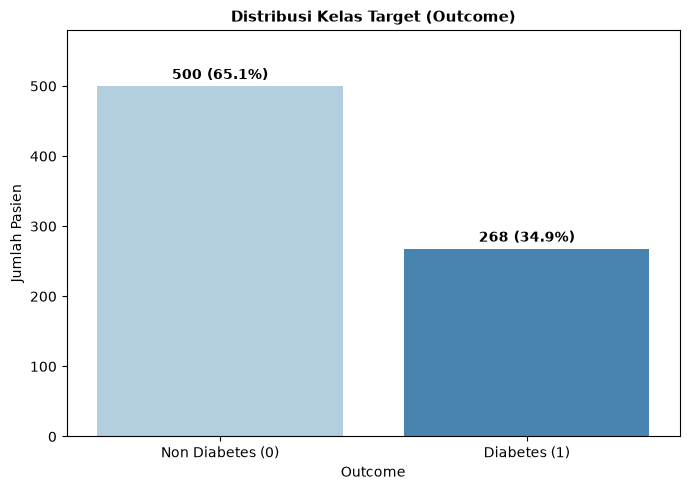

Berdasarkan hasil visualisasi di atas, dapat kita ketahui bahwa dataset ini imbalanced


In [76]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

counts = df["Outcome"].value_counts()
proportions = df["Outcome"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(x = counts.index, y = counts.values, hue = counts.index, palette = "Blues")

plt.title("Distribusi Kelas Target (Outcome)", fontsize=11, fontweight='bold')
plt.xlabel("Outcome")
plt.ylabel("Jumlah Pasien")
plt.xticks([0, 1], ["Non Diabetes (0)", "Diabetes (1)"])

if ax.get_legend():
    ax.get_legend().remove()

for i, count in enumerate(counts):
    pct =  proportions[i]
    ax.text(i, count + 10, f"{count} ({pct:.1f}%)", ha = "center", fontweight = "bold")

plt.ylim(0, max(counts) + 80)
plt.tight_layout()
plt.show()

print("Berdasarkan hasil visualisasi di atas, dapat kita ketahui bahwa dataset ini imbalanced")

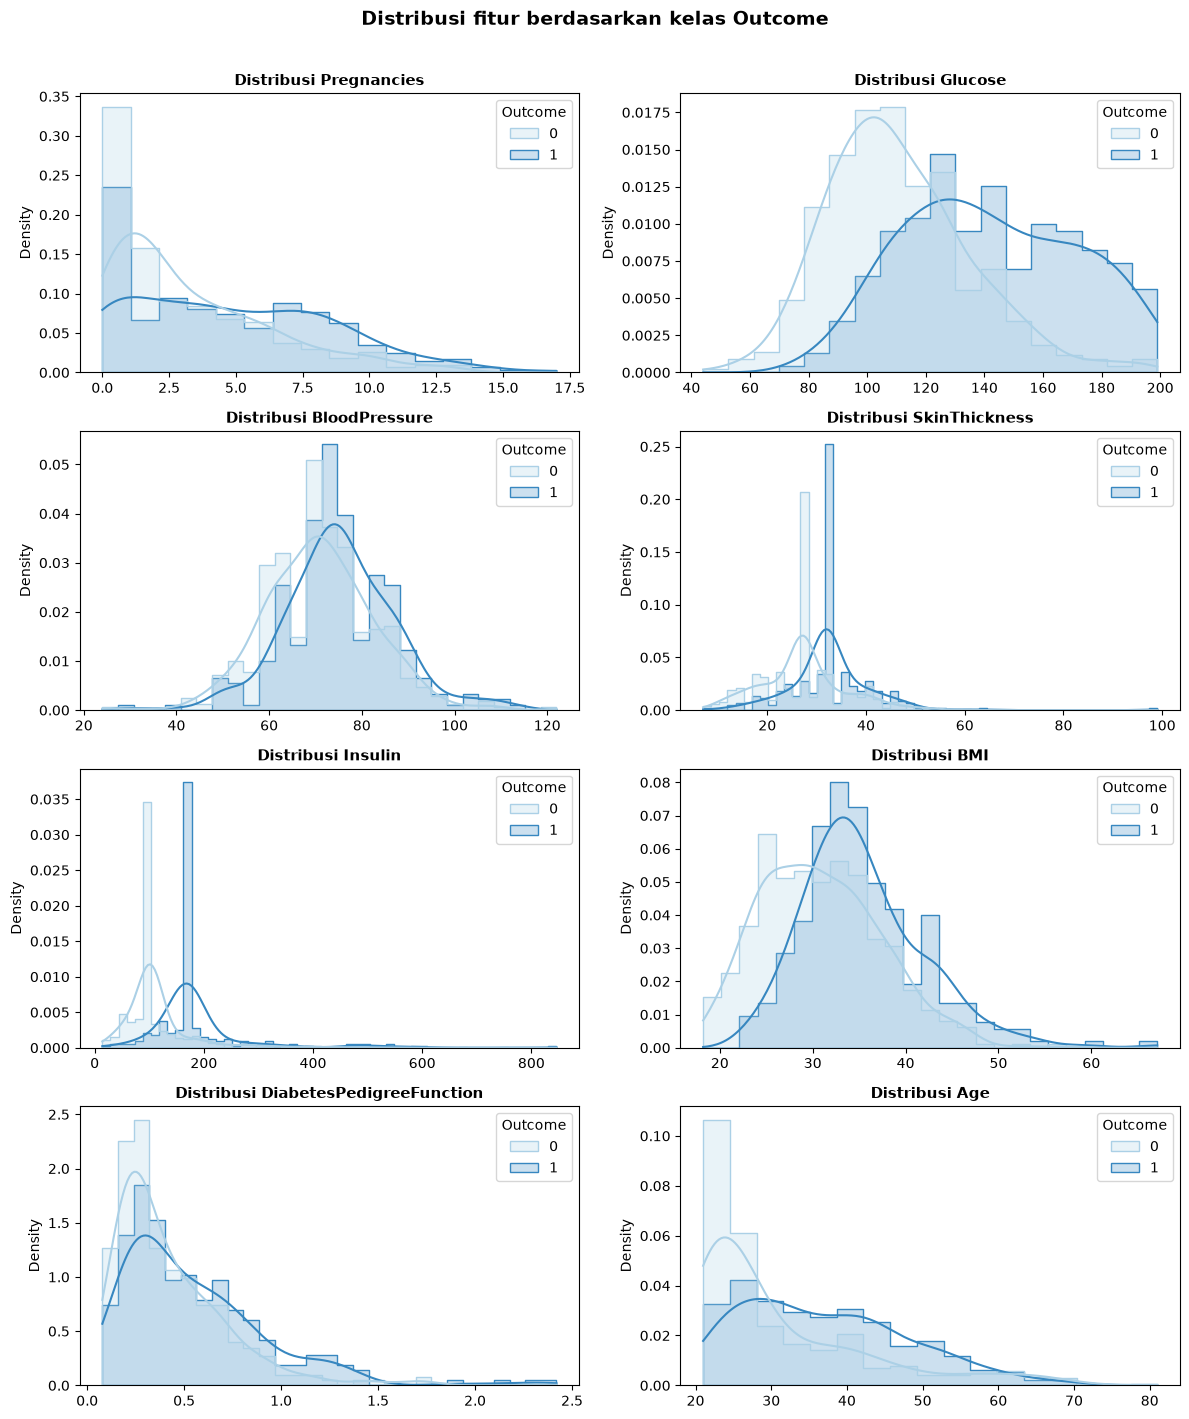

In [77]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = [col for col in df.columns if col != "Outcome"]

fig, axes = plt.subplots(nrows = 4, ncols = 2, figsize = (12, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data = df, 
                 x = col, 
                 hue = "Outcome", 
                 kde = True, 
                 palette = "Blues", 
                 element = "step", 
                 stat = "density", 
                 common_norm = False, 
                 ax = axes[i]
    )
    axes[i].set_title(f"Distribusi {col}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

plt.suptitle("Distribusi fitur berdasarkan kelas Outcome", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

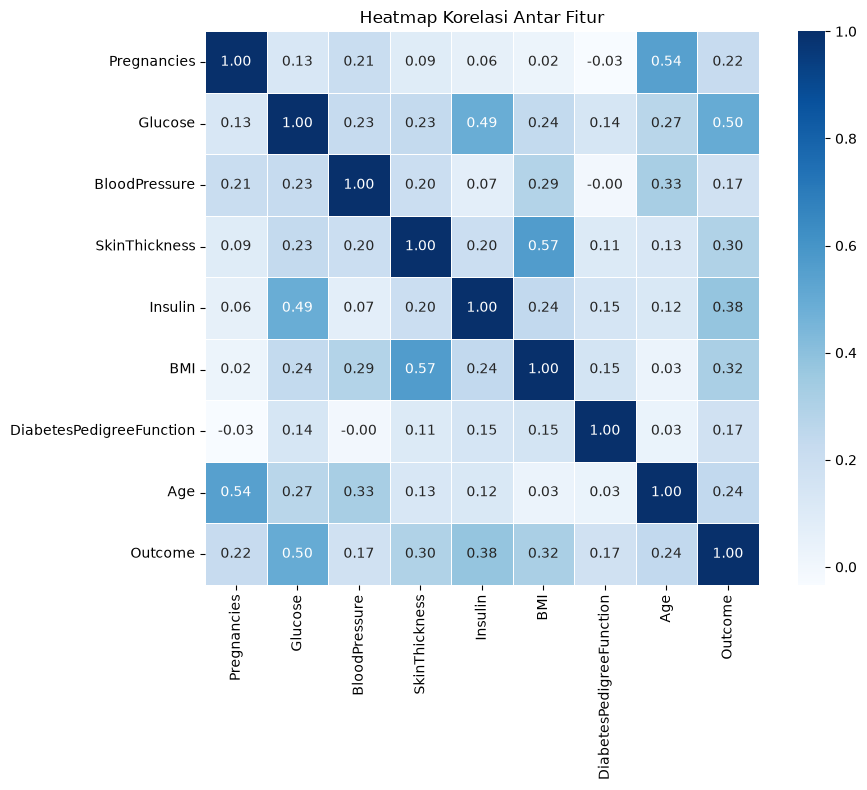

In [78]:
# Tampilkan heatmap korelasi antar fitur.
corr_matrix = df.corr()

plt.figure(figsize = (10, 8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "Blues",
    linewidth = 0.5,
    square = True
)

plt.title("Heatmap Korelasi Antar Fitur")
plt.tight_layout()
plt.show()

In [79]:
skewness = df.drop(columns = "Outcome").skew()

df_skew = pd.DataFrame({
    "Nilai Skewness": skewness,
    "Kategori": skewness.apply(
        lambda x: 'Sangat Miring (Highly Skewed)' if abs(x) > 1
        else ('Miring Sedang (Moderate)' if abs(x) >= 0.5 else 'Simetris (Normal)')
    )
}).sort_values(by = "Nilai Skewness", key = abs, ascending = False)

display(df_skew)

,Nilai Skewness,Kategori
Insulin,3.028046,Sangat Miring (Highly Skewed)
DiabetesPedigreeFunction,1.919911,Sangat Miring (Highly Skewed)
Age,1.129597,Sangat Miring (Highly Skewed)
Pregnancies,0.901674,Miring Sedang (Moderate)
SkinThickness,0.817477,Miring Sedang (Moderate)
BMI,0.606416,Miring Sedang (Moderate)
Glucose,0.532324,Miring Sedang (Moderate)
BloodPressure,0.140830,Simetris (Normal)


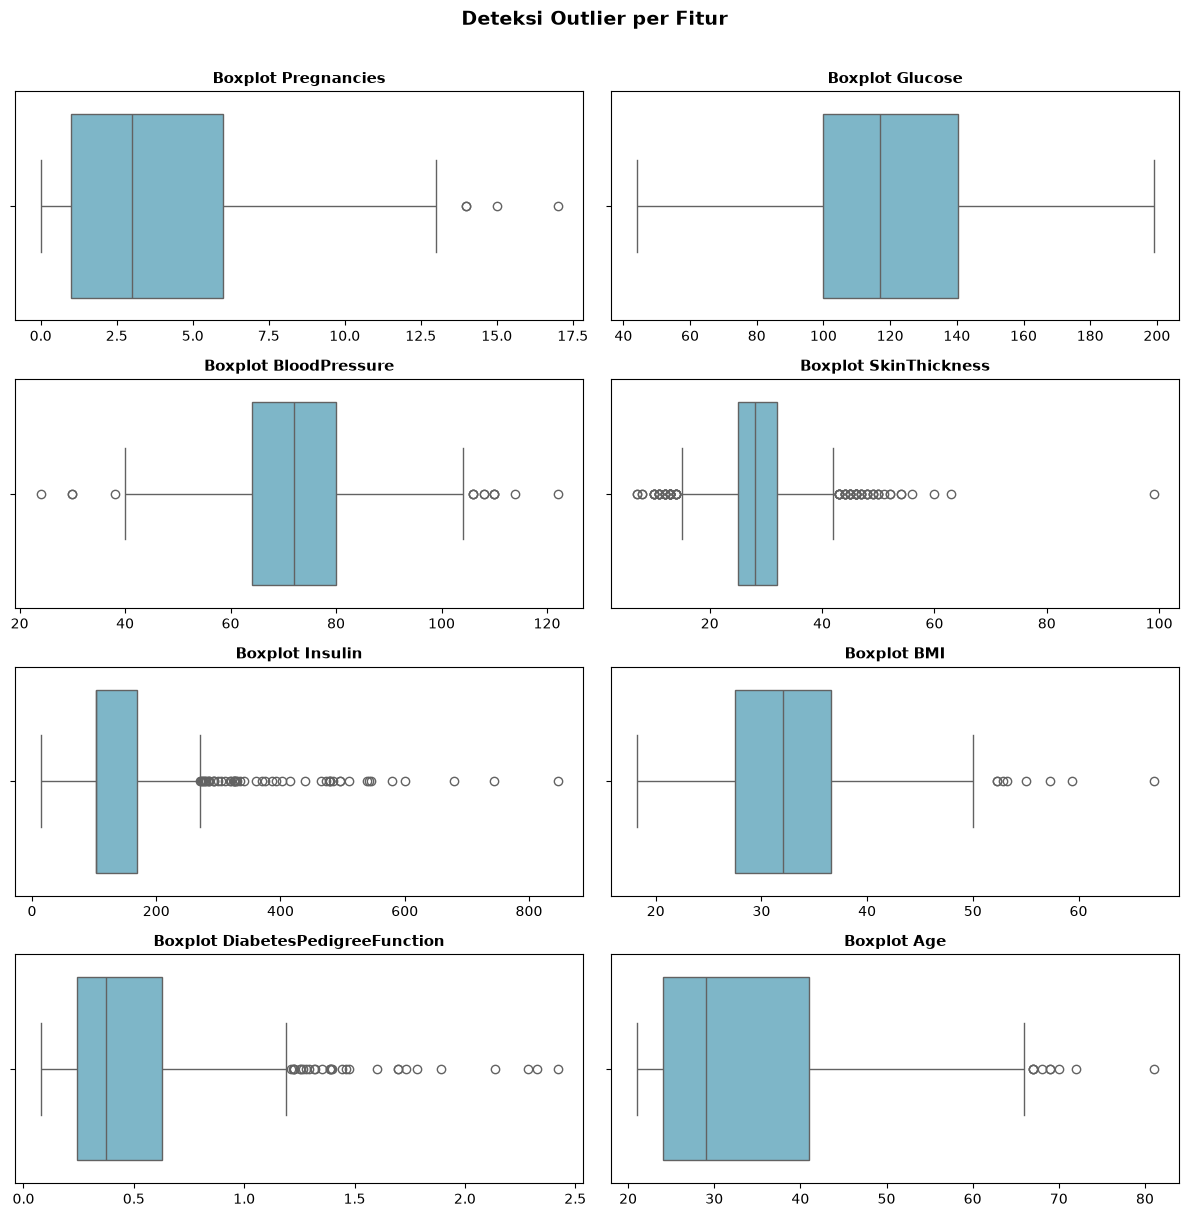

In [80]:
features = [col for col in df.columns if col != 'Outcome']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x=col, ax=axes[i], color='#72bcd4')
    axes[i].set_title(f'Boxplot {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Deteksi Outlier per Fitur', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [81]:
outlier_summary = []

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    percentage = (count / len(df)) * 100
    
    outlier_summary.append({
        'Fitur': col,
        'Jumlah Outlier': count,
        'Persentase (%)': round(percentage, 2)
    })

df_outlier = pd.DataFrame(outlier_summary).sort_values(by='Jumlah Outlier', ascending=False)
display(df_outlier)

,Fitur,Jumlah Outlier,Persentase (%)
3,SkinThickness,87,11.330000
4,Insulin,51,6.640000
6,DiabetesPedigreeFunction,29,3.780000
2,BloodPressure,14,1.820000
7,Age,9,1.170000
5,BMI,8,1.040000
0,Pregnancies,4,0.520000
1,Glucose,0,0.000000


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [82]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
cols_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[cols_zero] == 0).sum()
zero_percent = (zero_counts / len(df)) * 100

df_zero_info = pd.DataFrame({
    "Jumlah Nilai 0": zero_counts,
    "Persentase (%)": zero_percent.round(2)
}).sort_values(by = "Jumlah Nilai 0", ascending = False)

print("========== Jumlah Nilai 0 (Missing Value Implisit) ==========")
display(df_zero_info)

========== Jumlah Nilai 0 (Missing Value Implisit) ==========


,Jumlah Nilai 0,Persentase (%)
Glucose,0,0.000000
BloodPressure,0,0.000000
SkinThickness,0,0.000000
Insulin,0,0.000000
BMI,0,0.000000


In [95]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Tidak ditemukan nilai 0 pada kolom Glucose, BloodPressure, SkinThickness, Insulin, dan BMI")

Tidak ditemukan nilai 0 pada kolom Glucose, BloodPressure, SkinThickness, Insulin, dan BMI


In [96]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns = "Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify= y
)

print(f"Jumlah data training: {X_train.shape[0]} baris")
print(f"Jumlah data test: {X_test.shape[0]} baris")

Jumlah data training: 614 baris
Jumlah data test: 154 baris


In [97]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling berhasil dilakukan!")
print(f"Bentuk X_train_scaled: {X_train_scaled.shape}")
print(f"Bentuk X_test_scaled : {X_test_scaled.shape}")

Scaling berhasil dilakukan!
Bentuk X_train_scaled: (614, 8)
Bentuk X_test_scaled : (154, 8)


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [98]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb_model = GaussianNB()

gnb_model.fit(X_train_scaled, y_train)
print("Model Gaussian NB berhasil dilatih!")

Model Gaussian NB berhasil dilatih!


In [99]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = gnb_model.predict(X_test_scaled)
y_prob_gnb = gnb_model.predict_proba(X_test_scaled)[:, 1]

print("Prediksi label dan probabilitas berhasil disimpan!")
print("Contoh 5 hasil prediksi label:", y_pred_gnb[:5])
print("Contoh 5 probabilitas kelas 1:", y_prob_gnb[:5].round(4))

Prediksi label dan probabilitas berhasil disimpan!
Contoh 5 hasil prediksi label: [0 0 0 0 0]
Contoh 5 probabilitas kelas 1: [0.3946 0.2109 0.2328 0.1853 0.0061]


## 3.2 Logistic Regression

In [102]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
logreg_model = LogisticRegression(random_state=42)

logreg_model.fit(X_train_scaled, y_train)
print("Model Logistic Regression berhasil dilatih!")

Model Logistic Regression berhasil dilatih!


In [103]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_logreg = logreg_model.predict(X_test_scaled)
y_prob_logreg = logreg_model.predict_proba(X_test_scaled)[:, 1]

print("Prediksi label dan probabilitas Logistic Regression berhasil disimpan!")
print("Contoh 5 hasil prediksi label:", y_pred_logreg[:5])
print("Contoh 5 probabilitas kelas 1:", y_prob_logreg[:5].round(4))

Prediksi label dan probabilitas Logistic Regression berhasil disimpan!
Contoh 5 hasil prediksi label: [0 0 0 0 0]
Contoh 5 probabilitas kelas 1: [0.4774 0.0741 0.3701 0.3377 0.032 ]


# 4. Evaluasi Model

In [104]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
metrics_gnb = {
    'Model': 'Gaussian Naive Bayes',
    'Accuracy': accuracy_score(y_test, y_pred_gnb),
    'Precision': precision_score(y_test, y_pred_gnb),
    'Recall': recall_score(y_test, y_pred_gnb),
    'F1-Score': f1_score(y_test, y_pred_gnb)
}

metrics_logreg = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_logreg),
    'Precision': precision_score(y_test, y_pred_logreg),
    'Recall': recall_score(y_test, y_pred_logreg),
    'F1-Score': f1_score(y_test, y_pred_logreg)
}

df_metrics = pd.DataFrame([metrics_gnb, metrics_logreg])
display(df_metrics.round(4))


,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian Naive Bayes,0.727300,0.603400,0.648100,0.625000
1,Logistic Regression,0.707800,0.588200,0.555600,0.571400


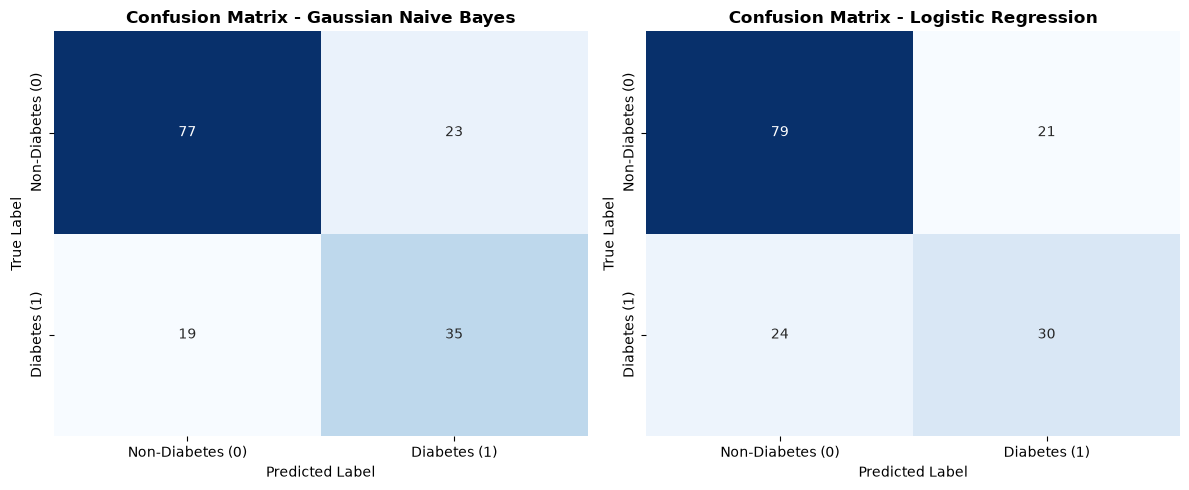

In [105]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Non-Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['Non-Diabetes (0)', 'Diabetes (1)'])
axes[0].set_title('Confusion Matrix - Gaussian Naive Bayes', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Non-Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['Non-Diabetes (0)', 'Diabetes (1)'])
axes[1].set_title('Confusion Matrix - Logistic Regression', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

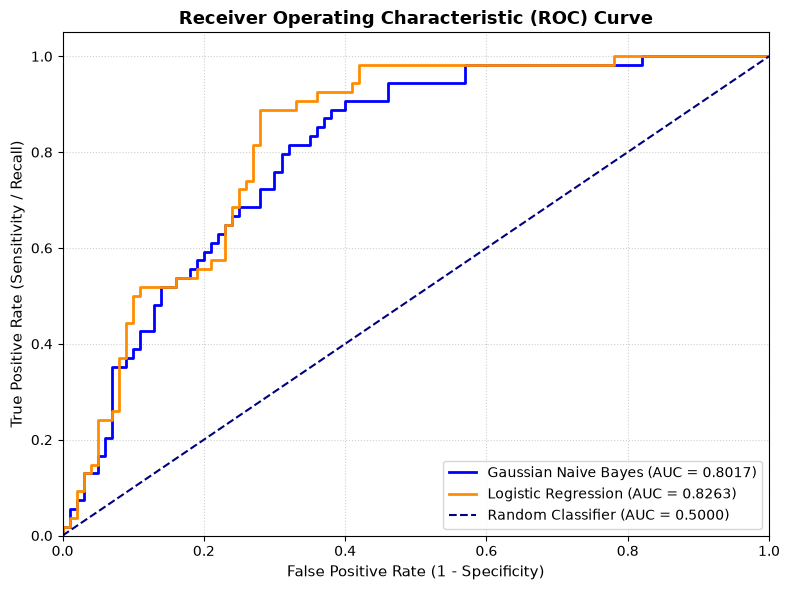

In [106]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)
auc_gnb = roc_auc_score(y_test, y_prob_gnb)

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
auc_logreg = roc_auc_score(y_test, y_prob_logreg)

plt.figure(figsize=(8, 6))

plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian Naive Bayes (AUC = {auc_gnb:.4f})', color='blue', lw=2)
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.4f})', color='darkorange', lw=2)

plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

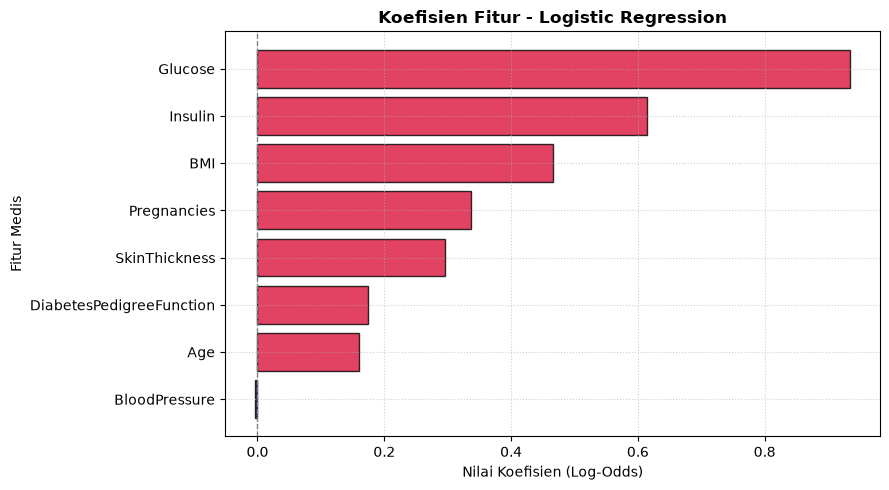

In [107]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg_model.coef_[0]
}).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(9, 5))
colors = ['crimson' if x > 0 else 'navy' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.8, edgecolor='black')

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.title('Koefisien Fitur - Logistic Regression', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Koefisien (Log-Odds)')
plt.ylabel('Fitur Medis')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

# Laporan Analisis Eksperimen Klasifikasi Diabetes

## 1. Eksplorasi Data (EDA) dan Kualitas Dataset

Eksperimen diawali dengan menguji kualifikasi data pada dataset **PIMA Indians Diabetes** yang memiliki **768 baris** dan **9 kolom**. 

Pemeriksaan statistik deskriptif menunjukkan bahwa dataset yang digunakan **sudah bersih dari *implicit missing values*** pada seluruh fitur medis utama:
* **`Glucose`:** Nilai minimum 44,0 (tidak ada nilai 0).
* **`BloodPressure`:** Nilai minimum 24,0 (tidak ada nilai 0).
* **`SkinThickness`:** Nilai minimum 7,0 (tidak ada nilai 0).
* **`Insulin`:** Nilai minimum 14,0 (tidak ada nilai 0).
* **`BMI`:** Nilai minimum 18,2 (tidak ada nilai 0).

Nilai `0` hanya ditemukan pada kolom `Pregnancies` (111 data) dan label `Outcome` (500 data), yang mana nilainya sah secara medis maupun logika. Oleh karena itu, tahap imputasi data secara logis **dilewati (*skipped*)** agar tidak mengubah distribusi asli dataset.

---

## 2. Preprocessing Data

* **Train-Test Split:** Data dibagi dengan rasio **80:20** (614 data *train* dan 154 data *test*). Penggunaan parameter `stratify=y` berhasil mempertahankan rasio target seimbang pada kedua set data, yaitu **~65% kelas Non-Diabetes (0)** dan **~35% kelas Diabetes (1)**.
* **Feature Scaling:** Pembobotan fitur dilakukan dengan `StandardScaler`. Metode `fit_transform` diterapkan khusus pada data *train*, sedangkan data *test* hanya di-`transform` menggunakan statistik ($\mu$ dan $\sigma$) milik data *train* demi mencegah terjadinya **data leakage**.

---

## 3. Perbandingan Performa Model (Threshold Default 0,5)

Evaluasi awal dilakukan pada *test set* (154 data) menggunakan *threshold* default 0,5. Hasil metrik kinerja kedua model dirangkum dalam tabel berikut:

| Metrik Evaluasi | Gaussian Naive Bayes | Logistic Regression | Selisih (GNB vs LogReg) |
| :--- | :---: | :---: | :---: |
| **Accuracy** | **0,7273** (72,73%) | 0,7078 (70,78%) | +1,95% |
| **Precision** | **0,6034** (60,34%) | 0,5882 (58,82%) | +1,52% |
| **Recall** | **0,6481** (64,81%) | 0,5556 (55,56%) | **+9,25%** |
| **F1-Score** | **0,6250** (62,50%) | 0,5714 (57,14%) | +5,36% |

Pada titik potong default 0,5, **Gaussian Naive Bayes mengungguli Logistic Regression di semua metrik**, dengan keunggulan paling mencolok pada nilai **Recall (+9,25%)**.

---

## 4. Analisis Diagnostics Visual

### A. Confusion Matrix
Dari 154 data uji (100 kelas Non-Diabetes dan 54 kelas Diabetes), rincian hasil prediksinya adalah:

* **Gaussian Naive Bayes:**
  * **True Negative (TN):** 77 orang
  * **False Positive (FP):** 23 orang
  * **False Negative (FN):** 19 orang
  * **True Positive (TP):** 35 orang
* **Logistic Regression:**
  * **True Negative (TN):** 79 orang
  * **False Positive (FP):** 21 orang
  * **False Negative (FN):** 24 orang
  * **True Positive (TP):** 30 orang

**Perspektif Medis:**
Dalam bidang kesehatan, kesalahan jenis **False Negative (FN)**—pasien diabetes yang dikira sehat—jauh lebih berbahaya daripada kesalahan *False Positive* (FP). Gaussian Naive Bayes mencatatkan angka FN lebih rendah (19 vs 24 pasien) serta berhasil mendeteksi pasien diabetes (TP) lebih banyak (35 vs 30 pasien).

### B. ROC-AUC Curve
* **Logistic Regression:** AUC = **0,8263**
* **Gaussian Naive Bayes:** AUC = **0,8017**

Meskipun Gaussian Naive Bayes unggul pada metrik evaluasi *threshold* 0,5, kurva ROC menunjukkan bahwa **Logistic Regression memiliki nilai AUC keseluruhan yang lebih tinggi**. 

Hal ini terjadi karena Gaussian Naive Bayes cenderung menghasilkan probabilitas yang sangat ekstrem (mendekati 0 atau 1) sehingga secara agresif memprediksi kelas positif pada *threshold* 0,5. Sebaliknya, Logistic Regression memiliki kemampuan pemisahan probabilitas yang lebih baik di berbagai batas variasi *threshold*.

---

## 5. Interpretabilitas Fitur (Koefisien Logistic Regression)

Nilai koefisien (*log-odds*) dari model Logistic Regression memberikan gambaran tingkat kepentingan setiap fitur numerik:

1. **`Glucose` (+0,9349):** Indikator paling dominan. Kenaikan kadar gula darah memiliki dorongan terbesar terhadap peningkatan risiko diabetes.
2. **`Insulin` (+0,6142):** Faktor pendukung terbesar kedua.
3. **`BMI` (+0,4661):** Faktor pendukung terbesar ketiga.
4. **Fitur Lainnya:** `Pregnancies` (+0,3372), `SkinThickness` (+0,2950), `DiabetesPedigreeFunction` (+0,1747), dan `Age` (+0,1598) seluruhnya berkontribusi positif.
5. **`BloodPressure` (-0,0042):** Memiliki nilai mendekati 0, menunjukkan bahwa tekanan darah hampir tidak memengaruhi prediksi diagnosis secara linear setelah dikontrol oleh variabel lainnya.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

# Kesimpulan dan Saran

## 1. Kesimpulan

Berdasarkan serangkaian eksperimen yang telah dilakukan pada dataset **PIMA Indians Diabetes**, dapat ditarik beberapa kesimpulan utama:

1. **Performansi Model pada Threshold Default (0,5):**
   * **Gaussian Naive Bayes (GNB)** menunjukkan performa yang lebih unggul dibandingkan Logistic Regression secara keseluruhan pada *threshold* bawaan. GNB meraih **Accuracy (72,73%)**, **Precision (60,34%)**, **Recall (64,81%)**, dan **F1-Score (62,50%)**.
   * Dalam konteks skrining medis, GNB terbukti lebih aman karena menghasilkan angka *False Negative* yang lebih minim (**19 pasien**) dibanding Logistic Regression (**24 pasien**).

2. **Kemampuan Pemisahan Kelas (ROC-AUC):**
   * **Logistic Regression** menghasilkan nilai **ROC-AUC yang lebih tinggi (0,8263)** dibandingkan GNB (**0,8017**). Ini membuktikan bahwa secara umum, Logistic Regression memiliki kemampuan pemisahan distribusi probabilitas antar-kelas yang lebih stabil jika dilakukan penyesuaian *threshold*.

3. **Signifikansi Fitur Medis:**
   * Analisis koefisien Logistic Regression mengonfirmasi bahwa **`Glucose` (+0,9349)**, **`Insulin` (+0,6142)**, dan **`BMI` (+0,4661)** merupakan tiga prediktor positif paling dominan yang meningkatkan risiko seseorang terdiagnosis diabetes. Sementara `BloodPressure` tidak memberikan pengaruh linear yang signifikan.

---

## 2. Saran

Untuk pengembangan eksperimen dan peningkatan performa model di masa mendatang, beberapa langkah perbaikan yang direkomendasikan adalah:

1. **Threshold Tuning pada Logistic Regression:**
   * Melakukan penurunan *decision threshold* pada Logistic Regression (misalnya dari 0,5 ke kisaran 0,35–0,40) untuk mendongkrak nilai *Recall* tanpa mengorbankan performa AUC-nya yang sudah bagus.

2. **Penanganan Imbalansi Kelas (Class Imbalance):**
   * Menerapkan teknik *resampling* seperti **SMOTE (Synthetic Minority Over-sampling Technique)** atau memanfaatkan parameter `class_weight='balanced'` pada Logistic Regression untuk membantu model mengenali pola kelas positif (Diabetes) dengan lebih sensitif.

3. **Feature Engineering & Interaksi Fitur:**
   * Membuat fitur turunan baru, seperti kalkulasi rasio `Glucose/Insulin` atau fitur interaksi antara `BMI` dan `Age`, untuk menangkap hubungan non-linear antar-fitur medis.

4. **Eksplorasi Algoritma Non-Linear:**
   * Menguji algoritma berbasis *ensemble learning* seperti **Random Forest**, **Gradient Boosting**, atau **XGBoost** yang dapat menangani pola hubungan non-linear dan kompleks antar-variabel medis dengan lebih baik dibanding model linier atau asumsi independensi Naive Bayes.